# Predictive Paradox — Power Demand Forecasting Pipeline

The required libraries were installed and imported into the environment.
All tools needed for data loading, cleaning, modelling, and evaluation were prepared.

In [106]:
!pip install lightgbm openpyxl xlrd -q

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error

## 1 — Power Data Was Loaded

The Excel file was read into a dataframe using a try/except engine fallback.
The datetime column was parsed, set as the index, and sorted chronologically.

In [107]:
try:
    df_power = pd.read_excel('PGCB_date_power_demand.xlsx', parse_dates=[0], engine='openpyxl')
except Exception:
    df_power = pd.read_excel('PGCB_date_power_demand.xlsx', parse_dates=[0], engine='xlrd')

df_power.rename(columns={df_power.columns[0]: 'datetime'}, inplace=True)
df_power['datetime'] = pd.to_datetime(df_power['datetime'])
df_power.set_index('datetime', inplace=True)
df_power = df_power.sort_index()
print('Shape:', df_power.shape)
df_power.head()

Shape: (92650, 14)


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


## 2 — The Power Data Was Inspected

The date range, null counts, and descriptive statistics of demand_mw were printed.
Extreme or unexpected values were identified before any cleaning was applied.

In [108]:
print('Date range:', df_power.index.min(), 'to', df_power.index.max())
print('\nNull counts:')
print(df_power.isnull().sum())
print('\nDemand stats:')
print(df_power['demand_mw'].describe())

Date range: 2015-04-19 00:00:00 to 2025-06-17 12:00:00

Null counts:
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   22133
wind                    73974
india_bheramara_hvdc        0
india_tripura               0
india_adani             85312
nepal                   87299
remarks                 86257
dtype: int64

Demand stats:
count     92650.000000
mean       8819.646044
std        2772.150108
min           6.000000
25%        6812.250000
50%        8422.000000
75%       10633.000000
max      156050.000000
Name: demand_mw, dtype: float64


## 3 — Missing Values Were Filled by Interpolation

The original demand column was preserved as a backup before any changes were made.
Gaps were filled using linear interpolation between the nearest valid values.

In [109]:
df_power['demand_mw_original'] = df_power['demand_mw'].copy()
df_power['demand_mw'] = pd.to_numeric(df_power['demand_mw'], errors='coerce')
df_power['demand_mw'] = df_power['demand_mw'].interpolate(method='linear')
print('Missing values after interpolation:', df_power['demand_mw'].isnull().sum())

Missing values after interpolation: 0


## 4 — Rolling IQR Bounds Were Computed

A 168-hour (one week) rolling window was applied to calculate local Q1, Q3, and IQR at every point.
Upper and lower bounds were set at 1.5 × IQR beyond Q3 and Q1 respectively.

In [110]:
rolling_window = df_power['demand_mw'].rolling(window=168, center=True, min_periods=1)

q1            = rolling_window.quantile(0.25)
q3            = rolling_window.quantile(0.75)
iqr           = q3 - q1
upper_bound   = q3 + 1.5 * iqr
lower_bound   = q1 - 1.5 * iqr
rolling_median = rolling_window.median()

print('Sample upper bound at index 200:', round(upper_bound.iloc[200], 2))

Sample upper bound at index 200: 7672.75


## 5 — Anomalous Spikes Were Detected and Replaced

Values that fell outside the rolling IQR bounds were flagged as anomalies.
Each flagged value was replaced with the local rolling median of its 168-hour window.

In [111]:
anomalies = (df_power['demand_mw'] < lower_bound) | (df_power['demand_mw'] > upper_bound)
df_power.loc[anomalies, 'demand_mw'] = rolling_median[anomalies]
print(f'Total anomalies replaced: {anomalies.sum()}')

Total anomalies replaced: 210


/tmp/ipykernel_9004/3008056685.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 6209.   6187.5  6187.5  6187.5  6187.5  6187.5  6277.5  6270.   6260.5
  6747.   5841.   5517.5  5499.5  5472.   5462.5  5462.5  5489.5  5499.5
  5517.5  5542.5  7272.   6705.   6705.   6705.   6705.   6705.   6685.5
  6626.5  6740.5  6756.   6756.   6698.5  6914.5  7215.   7544.   6466.
  7066.5  5344.   6016.5  6374.5  7359.5  7359.5  7359.5  7339.5  7313.5
  7290.   7271.5  7263.   7240.   8173.   8173.   7884.5  7884.5  7884.5
  8207.   8190.   5677.5  5571.5  5933.5  5874.   6775.   6775.   6775.
  7503.5  7503.5  7503.5  7503.5  5953.5  8155.   7922.5  9579.   9121.5
  7910.5  7790.5  9708.5  9594.5  6796.5  9123.  10292.5 10285.  10276.5
 10259.  10223.  10187.  10164.5 10148.  10132.  10107.  10107.  10107.
 10107.  10107.  10107.  10734.  10734.  10734.  10734.  10734.  10734.
 10208.5 11282.  11282.  11282.  11

## 6 — The Cleaning Result Was Visualised

The first 60 days of original and cleaned demand were plotted for comparison.
Red dots were used to mark the exact positions where anomalies were replaced.

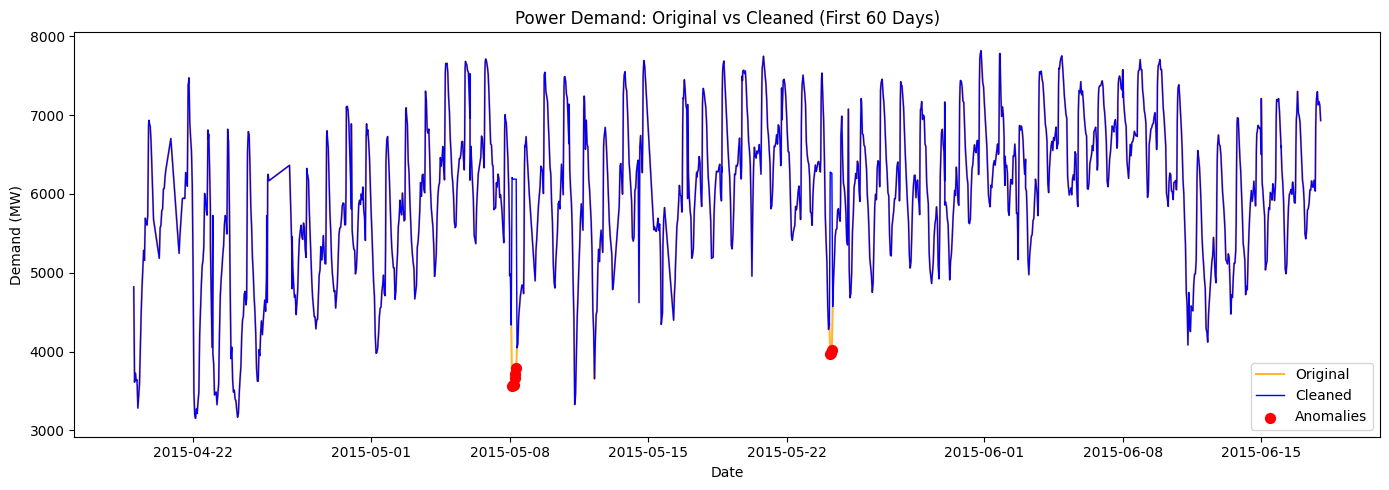

In [112]:
start_date = df_power.index.min()
end_date   = start_date + pd.Timedelta(days=60)
df_slice   = df_power.loc[start_date:end_date]

plt.figure(figsize=(14, 5))
plt.plot(df_slice.index, df_slice['demand_mw_original'], label='Original', color='orange', alpha=0.8)
plt.plot(df_slice.index, df_slice['demand_mw'],          label='Cleaned',  color='blue',   linewidth=1)

anomalies_slice = df_slice[df_slice['demand_mw_original'] != df_slice['demand_mw']]
plt.scatter(anomalies_slice.index, anomalies_slice['demand_mw_original'],
            color='red', label='Anomalies', s=50, zorder=5)

plt.title('Power Demand: Original vs Cleaned (First 60 Days)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

## 7 — Weather Data Was Loaded

The CSV file was read with three metadata rows skipped before the column header.
Only temperature, humidity, and precipitation columns were retained by keyword matching.

In [113]:
try:
    df_weather = pd.read_csv('weather_data(Sheet1).csv', skiprows=3, parse_dates=['time'])
except FileNotFoundError:
    df_weather = pd.read_csv('weather_data_Sheet1_.csv', skiprows=3, parse_dates=['time'])

df_weather  = df_weather.set_index('time')
weather_cols = [c for c in df_weather.columns
                if any(k in c for k in ['temperature', 'humidity', 'precipitation'])]
df_weather  = df_weather[weather_cols]
print('Weather shape:', df_weather.shape)
df_weather.head()

Weather shape: (107304, 5)


,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),soil_temperature_0_to_7cm (°C)
time,,,,,
2014-01-01 00:00:00,13.9,89,13.3,0.0,16.4
2014-01-01 01:00:00,13.6,91,13.2,0.0,16.0
2014-01-01 02:00:00,13.3,91,12.8,0.0,15.7
2014-01-01 03:00:00,13.0,92,12.5,0.0,15.4
2014-01-01 04:00:00,12.7,93,12.2,0.0,15.2


## 8 — Economic Data Was Loaded and Reshaped

Rows were filtered to GDP, Population, and Industry indicators only.
The wide-format table was melted and pivoted into one row per year, then forward-filled.

In [114]:
df_econ = pd.read_csv('economic_full_1.csv')

df_econ_filtered = df_econ[
    df_econ['Indicator Name'].str.contains('GDP|Population|Industry', case=False, na=False)
].copy()
df_econ_filtered = df_econ_filtered.drop(columns=['Country Name', 'Indicator Code'], errors='ignore')

year_cols = [col for col in df_econ_filtered.columns if str(col).isdigit()]
id_vars   = [col for col in df_econ_filtered.columns if col not in year_cols]

df_econ_melted = pd.melt(df_econ_filtered, id_vars=id_vars,
                          value_vars=year_cols, var_name='Year', value_name='Value')
df_econ_pivot  = pd.pivot_table(df_econ_melted, index='Year',
                                 columns='Indicator Name', values='Value')
df_econ_pivot.index = pd.to_numeric(df_econ_pivot.index)
df_econ_pivot  = df_econ_pivot.ffill()
print('Economic pivot shape:', df_econ_pivot.shape)

Economic pivot shape: (66, 333)


## 9 — All Three Datasets Were Merged

Power and weather data were joined on their shared hourly datetime index.
Annual economic indicators were then attached to each row by matching calendar year.

In [115]:
df_master = df_power.merge(df_weather, left_index=True, right_index=True, how='left')
df_master[weather_cols] = df_master[weather_cols].interpolate(method='linear')
df_master['year'] = df_master.index.year
df_master = df_master.merge(df_econ_pivot, left_on='year', right_index=True, how='left')
df_master = df_master.ffill().bfill()
print('Master dataframe shape:', df_master.shape)
df_master[['demand_mw'] + weather_cols[:2] + ['year']].head()

Master dataframe shape: (92650, 354)


,demand_mw,temperature_2m (°C),relative_humidity_2m (%),year
2015-04-19 00:00:00,4821.0,25.7,87.0,2015
2015-04-19 01:00:00,3612.0,25.3,88.0,2015
2015-04-19 02:00:00,3727.0,24.9,90.0,2015
2015-04-19 03:00:00,3632.0,25.0,90.0,2015
2015-04-19 04:00:00,3641.0,25.2,91.0,2015


## 10 — Only Core Columns Were Selected

The master dataframe was narrowed to generation, demand, and the three weather variables.
All other merged columns were dropped to avoid introducing irrelevant noise.

In [116]:
strict_cols = ['generation_mw', 'demand_mw', weather_cols[0], weather_cols[1], weather_cols[2]]
strict_cols = [c for c in strict_cols if c in df_master.columns]

df_engineered = df_master[strict_cols].copy()
print('Selected columns:', df_engineered.columns.tolist())
print('Shape:', df_engineered.shape)

Selected columns: ['generation_mw', 'demand_mw', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)']
Shape: (92650, 5)


## 11 — Cyclical Calendar Features Were Engineered

Hour and day-of-week were encoded as sine and cosine pairs so the model sees them as circular.
The raw linear columns were then dropped and an is_weekend flag and month column were added.

In [117]:
df_engineered['hour']      = df_engineered.index.hour
df_engineered['dayofweek'] = df_engineered.index.dayofweek
df_engineered['month']     = df_engineered.index.month

df_engineered['hour_sin']      = np.sin(2 * np.pi * df_engineered['hour']      / 24)
df_engineered['hour_cos']      = np.cos(2 * np.pi * df_engineered['hour']      / 24)
df_engineered['dayofweek_sin'] = np.sin(2 * np.pi * df_engineered['dayofweek'] / 7)
df_engineered['dayofweek_cos'] = np.cos(2 * np.pi * df_engineered['dayofweek'] / 7)
df_engineered['month_sin']     = np.sin(2 * np.pi * df_engineered['month']     / 12)
df_engineered['month_cos']     = np.cos(2 * np.pi * df_engineered['month']     / 12)
df_engineered['is_weekend']    = (df_engineered['dayofweek'] >= 5).astype(int)

df_engineered = df_engineered.drop(columns=['hour', 'dayofweek', 'month'])
print('Calendar features added. Total columns:', df_engineered.shape[1])

Calendar features added. Total columns: 12


## 12 — Demand Lag Features Were Created

Demand values from 1, 2, 24, and 48 hours in the past were added as separate columns.
A 24-hour rolling mean was also computed on the lag-1 shifted series to avoid data leakage.

In [118]:
df_engineered['lag_1']          = df_engineered['demand_mw'].shift(1)
df_engineered['lag_2']          = df_engineered['demand_mw'].shift(2)
df_engineered['lag_24']         = df_engineered['demand_mw'].shift(24)
df_engineered['lag_48']         = df_engineered['demand_mw'].shift(48)
df_engineered['rolling_24h_mean'] = df_engineered['demand_mw'].shift(1).rolling(window=24).mean()

print(df_engineered[['demand_mw', 'lag_1', 'lag_24', 'lag_48', 'rolling_24h_mean']].tail())

                     demand_mw    lag_1   lag_24   lag_48  rolling_24h_mean
2025-06-17 08:00:00    11896.0  11745.0  13155.0  13779.0      13856.458333
2025-06-17 09:00:00    12290.0  11896.0  13569.0  14143.0      13804.000000
2025-06-17 10:00:00    12443.0  12290.0  13816.0  14069.0      13750.708333
2025-06-17 11:00:00    12826.0  12443.0  14226.0  14091.0      13693.500000
2025-06-17 12:00:00    13139.0  12826.0  14125.0  14065.0      13635.166667


## 13 — Momentum and Weather Lag Features Were Added

Momentum features were derived as differences between existing lag columns.
Temperature lags of 1 and 2 hours were added to capture delayed weather effects.

In [119]:
df_engineered['momentum_1h']  = df_engineered['lag_1'] - df_engineered['lag_2']
df_engineered['momentum_24h'] = df_engineered['lag_1'] - df_engineered['lag_24']

temp_col_raw  = weather_cols[0]
temp_col_safe = re.sub('[^A-Za-z0-9_]+', '_', temp_col_raw).strip('_')
df_engineered = df_engineered.rename(columns={temp_col_raw: temp_col_safe})

df_engineered['temp_lag_1'] = df_engineered[temp_col_safe].shift(1)
df_engineered['temp_lag_2'] = df_engineered[temp_col_safe].shift(2)

print('Total feature columns now:', df_engineered.shape[1])

Total feature columns now: 21


## 14 — Target Variable Was Created and Nulls Were Dropped

The demand column was shifted by -1 so each row's label is the next hour's actual demand.
All rows containing NaN values from lags or the target shift were safely removed.

In [120]:
df_engineered['target_demand_mw'] = df_engineered['demand_mw'].shift(-1)

df_engineered = df_engineered.rename(
    columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', str(x)).strip('_')
)
df_engineered = df_engineered.dropna()

print('Final shape:', df_engineered.shape)
print('Columns:', df_engineered.columns.tolist())

Final shape: (92601, 22)
Columns: ['generation_mw', 'demand_mw', 'temperature_2m_C', 'relative_humidity_2m', 'apparent_temperature_C', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'is_weekend', 'lag_1', 'lag_2', 'lag_24', 'lag_48', 'rolling_24h_mean', 'momentum_1h', 'momentum_24h', 'temp_lag_1', 'temp_lag_2', 'target_demand_mw']


## 15 — A Chronological 80/20 Train/Test Split Was Applied

Features and target were separated into X and y.
The first 80% of rows by time were used for training; the remaining 20% were held out for testing.

In [210]:
X = df_engineered.drop(columns=['target_demand_mw', 'temp_lag_1' , 'temp_lag_2', 'temperature_2m_C', 'is_weekend'])
y = df_engineered['target_demand_mw']

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f'Training rows : {len(X_train)}')
print(f'Test rows     : {len(X_test)}')
print(f'Train period  : {X_train.index.min()} to {X_train.index.max()}')
print(f'Test period   : {X_test.index.min()} to {X_test.index.max()}')

Training rows : 74080
Test rows     : 18521
Train period  : 2015-04-21 18:30:00 to 2023-06-07 08:00:00
Test period   : 2023-06-07 09:00:00 to 2025-06-17 11:00:00


## 16 — The LightGBM Model Was Trained and Evaluated

The upgraded LightGBM regressor was fitted exclusively on the training partition.
MAPE was then calculated on the unseen test set and feature importances were plotted.

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2769
[LightGBM] [Info] Number of data points in the train set: 74080, number of used features: 17
[LightGBM] [Info] Start training from score 8163.093656
Test MAPE: 1.87%


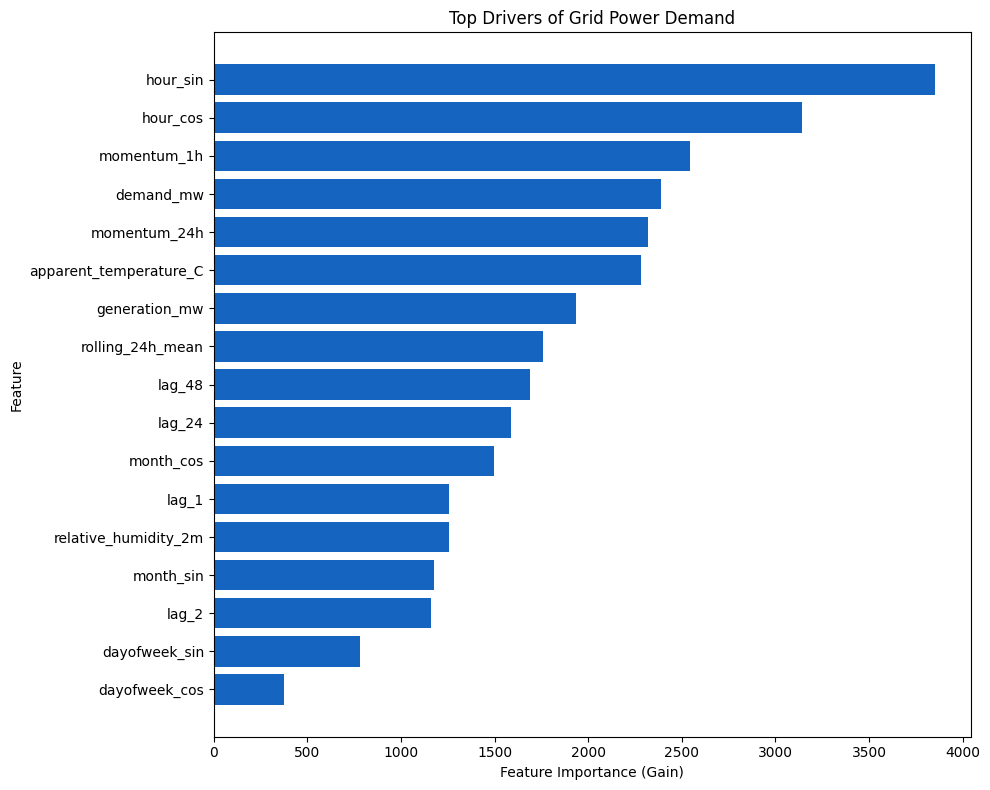

In [211]:
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=63,
    colsample_bytree=0.8,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mape   = mean_absolute_percentage_error(y_test, y_pred)
print(f'Test MAPE: {mape:.2%}')

importance_df = (
    pd.DataFrame({'Feature': X_train.columns, 'Importance': model.feature_importances_})
    .sort_values('Importance', ascending=True)
)
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#1565C0')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.title('Top Drivers of Grid Power Demand')
plt.tight_layout()
plt.show()